In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", device)

Device: cuda


In [5]:
data_root = "jelly_data"

train_dir = os.path.join(data_root, "train")
test_dir = os.path.join(data_root, "test")

In [6]:
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [7]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)

Classes: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']
Num classes: 6


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [9]:
class UnifiedOvAModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        backbone = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        in_features = backbone.fc.in_features
        
        self.heads = nn.ModuleList([
            nn.Linear(in_features, 1) for _ in range(num_classes)
        ])
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        
        outputs = [head(x) for head in self.heads]
        return torch.cat(outputs, dim=1)

In [10]:
model = UnifiedOvAModel(NUM_CLASSES).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10

c:\Users\jadeu\anaconda3\envs\aiml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\jadeu\anaconda3\envs\aiml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
def to_ova(labels, num_classes):
    out = torch.zeros(labels.size(0), num_classes).to(device)
    out[torch.arange(labels.size(0)), labels] = 1
    return out

In [12]:
scaler = torch.cuda.amp.GradScaler()
losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        ova_labels = to_ova(labels, NUM_CLASSES)
        
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, ova_labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {epoch_loss:.4f}")

C:\Users\jadeu\AppData\Local\Temp\ipykernel_4848\3582908411.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\jadeu\AppData\Local\Temp\ipykernel_4848\3582908411.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10 Loss: 0.4963
Epoch 2/10 Loss: 0.1931
Epoch 3/10 Loss: 0.0975
Epoch 4/10 Loss: 0.0576
Epoch 5/10 Loss: 0.0422
Epoch 6/10 Loss: 0.0420
Epoch 7/10 Loss: 0.0334
Epoch 8/10 Loss: 0.0323
Epoch 9/10 Loss: 0.0237
Epoch 10/10 Loss: 0.0206


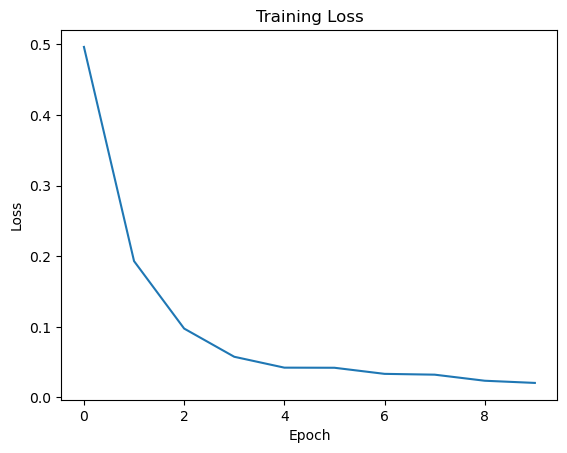

In [13]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [15]:
acc = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", acc)

Test Accuracy: 0.95


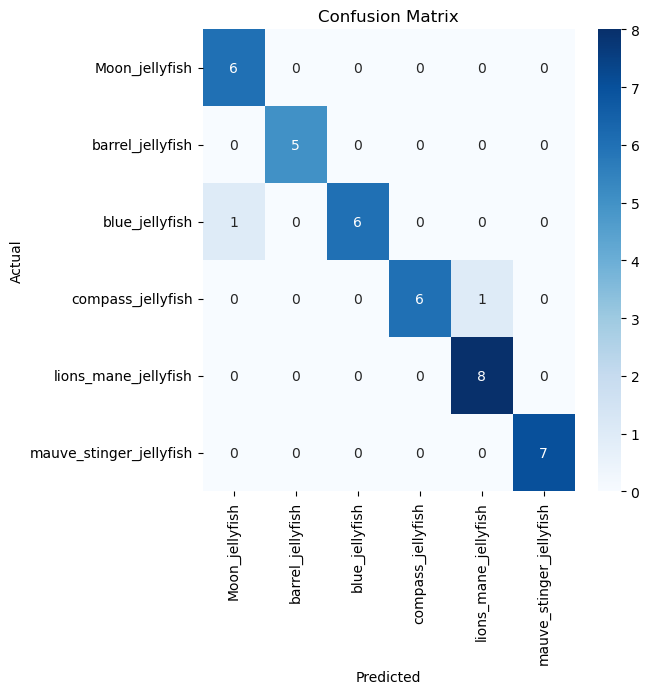

In [16]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
torch.save(model.state_dict(), "jellyfish.pth")
print("Model saved!")

Model saved!


In [20]:
from PIL import Image

def predict_image(img_path):
    image = Image.open(img_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.sigmoid(outputs)   # IMPORTANT for OvA
        
        pred = torch.argmax(probs, dim=1).item()
    
    return pred, probs.cpu().numpy()[0]

In [21]:
img_path = "03.jpg"   # change path

pred, probs = predict_image(img_path)

print("Predicted Class:", class_names[pred])
print("OvA Probabilities:", probs)

Predicted Class: blue_jellyfish
OvA Probabilities: [0.00636186 0.00518354 0.9940194  0.01064488 0.0160352  0.00564981]
